# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)

---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [4]:
# Importa las cuatro librerías con sus alias convencionales
# tu código aquí
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Una vez que las importes, descomenta estas líneas para verificar las versiones:
print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')

numpy   2.0.2
pandas  2.3.3
seaborn 0.13.2


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [23]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'
# tu código aquí
# Cargar el dataset (asegúrate de que el CSV esté en la carpeta data/) 
ruta_archivo = '/Users/USUARIO/F12-Programacion/practicas/python/analisisdeDatos/data/star_dataset.csv'
stars = pd.read_csv(ruta_archivo) 


print(stars.head()) 
print(f"Dimensiones: {stars.shape}") 
print(stars.dtypes) 
# Muestra las primeras 5 filas del DataFrame
# tu código aquí


             Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  \
0          Altair      16.594171           9.979192       1.632650   
1           Deneb    2600.490723      196002.627856     202.970526   
2  Barnard's Star       6.052616           4.893716       0.222711   
3         Polaris     322.601002        2196.241934      37.546813   
4  Barnard's Star       5.902392          -1.496486       0.192359   

   Temperature (K) Spectral Class  
0      7509.294247            A7V  
1      8503.284796           A2Ia  
2      3165.959639           M4Ve  
3      6048.326915           F7Ib  
4      3130.602069           M4Ve  
Dimensiones: (1000, 6)
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [26]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
# tu código aquí
print("Dimensiones del dataset:")
print(stars.shape)
print("\nTipos de datos:")
print(stars.dtypes)

Dimensiones del dataset:
(1000, 6)

Tipos de datos:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


In [25]:
# Obtén el resumen estadístico de las columnas numéricas
# tu código aquí
stars.describe()

,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,295.505327,19644.909442,86.960696,9983.486779
std,541.478403,42223.595017,213.850005,7906.973529
min,3.877798,-4.993141,0.068087,2750.183163
25%,11.716853,10.441039,1.664479,3940.020856
50%,52.031435,171.097809,5.845444,7379.007975
75%,322.865874,10500.577117,33.719778,12055.975095
max,2600.490723,196004.854081,887.097936,28044.279272


In [24]:
# Cuenta los valores nulos por columna
# tu código aquí
print("Valores nulos por columna:")
print(stars.isnull().sum())

Valores nulos por columna:
Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64


---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [36]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
# tu código aquí

clases_espectrales = stars['Spectral Class'].value_counts()
print(f"Total de clases espectrales: {len(clases_espectrales)}")
print("\nPrimeras 10 clases más frecuentes:")
print(clases_espectrales.head(10))

Total de clases espectrales: 28

Primeras 10 clases más frecuentes:
Spectral Class
A7V        74
A1V        73
A9II       48
B1III      45
M3.5V      45
M2Iab      44
G8III      39
M4Ve       38
K1.5III    38
A0V        38
Name: count, dtype: int64


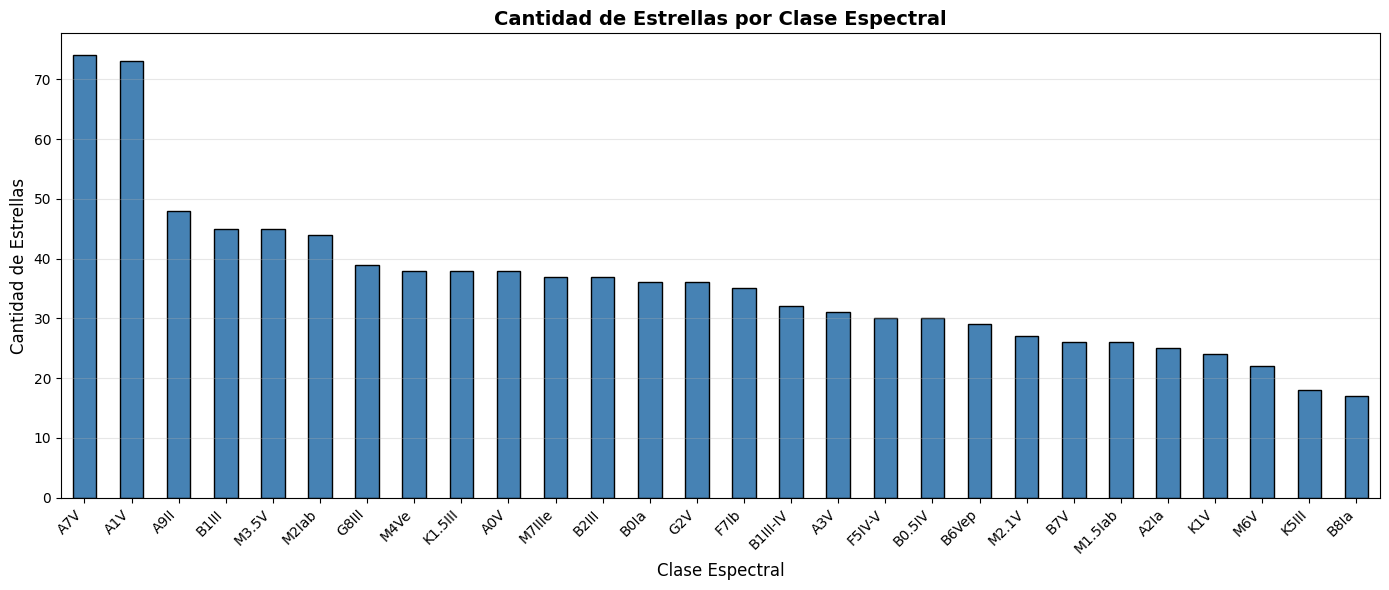

In [35]:
# Crear una gráfica de barras con las clases espectrales y sus frecuencias
# Puedes usar matplotlib.pyplot.bar() o .plot(kind='bar')
# tu código aquí

plt.figure(figsize=(14, 6))
clases_espectrales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cantidad de Estrellas por Clase Espectral', fontsize=14, fontweight='bold')
plt.xlabel('Clase Espectral', fontsize=12)
plt.ylabel('Cantidad de Estrellas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [30]:
# ── Enfoque 1: ciclo for ──────────────────────────────────────────────────────
tipo_objetivo = 'A7V'

# Paso 1: filtra el DataFrame para obtener solo las estrellas de tipo_objetivo (clase espectral)
# filtrado = ...
# tu código aquí
a7v_stars = stars[stars['Spectral Class'] == 'A7V']

suma = 0
contador = 0


for temp in a7v_stars['Temperature (K)']:
    suma += temp
    contador += 1

# Calcular media
temp_media_a7v_manual = suma / contador

print(f"Temperatura media de A7V (ciclo for): {temp_media_a7v_manual:.2f} K")
print(f"Número de estrellas A7V: {contador}")

# Paso 2: recorre filtrado['Temperature (K)'] con un for
# acumula la suma y el conteo (n)
# tu código aquí
temp_por_clase = stars.groupby('Spectral Class')['Temperature (K)'].mean()

# Verificar que A7V coincida con el resultado anterior
temp_media_a7v_groupby = temp_por_clase['A7V']

print(f"Temperatura media de A7V (groupby): {temp_media_a7v_groupby:.2f} K")
print(f"\n¿Coinciden los resultados? {abs(temp_media_a7v_manual - temp_media_a7v_groupby) < 0.01}")
print(f"\nTemperatura media de todas las clases espectrales:")
print(temp_por_clase.sort_values(ascending=False).head(10))

# Calcula la media y guárdala en media_manual
# media_manual = suma / n
# tu código aquí
temperaturas = stars['Temperature (K)'].values

media_temp = np.mean(temperaturas)
mediana_temp = np.median(temperaturas)
desv_temp = np.std(temperaturas)

print(f"Media de temperatura: {media_temp:.2f} K")
print(f"Mediana de temperatura: {mediana_temp:.2f} K")
print(f"Desviación estándar: {desv_temp:.2f} K")


Temperatura media de A7V (ciclo for): 7550.18 K
Número de estrellas A7V: 74
Temperatura media de A7V (groupby): 7550.18 K

¿Coinciden los resultados? True

Temperatura media de todas las clases espectrales:
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
Name: Temperature (K), dtype: float64
Media de temperatura: 9983.49 K
Mediana de temperatura: 7379.01 K
Desviación estándar: 7903.02 K


### Comparación: `for` vs. pandas

Con el ciclo `for` calculaste la media de **una sola clase espectral** en varias líneas.
Ahora verás cómo pandas obtiene la media de **todas las clases a la vez** en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de `A7V`
coincida con el valor que obtuviste con el `for`.

In [32]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
# tu código aquí
temp_por_clase = stars.groupby('Spectral Class')['Temperature (K)'].mean()

# Verificar que A7V coincida con el resultado anterior
temp_media_a7v_groupby = temp_por_clase['A7V']

print(f"Temperatura media de A7V (groupby): {temp_media_a7v_groupby:.2f} K")
print(f"\n¿Coinciden los resultados? {abs(temp_media_a7v_manual - temp_media_a7v_groupby) < 0.01}")
print(f"\nTemperatura media de todas las clases espectrales:")
print(temp_por_clase.sort_values(ascending=False).head(10))


Temperatura media de A7V (groupby): 7550.18 K

¿Coinciden los resultados? True

Temperatura media de todas las clases espectrales:
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
Name: Temperature (K), dtype: float64


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20868\3663105101.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stars_top, x='Spectral Class', y='Temperature (K)', palette='Set2')


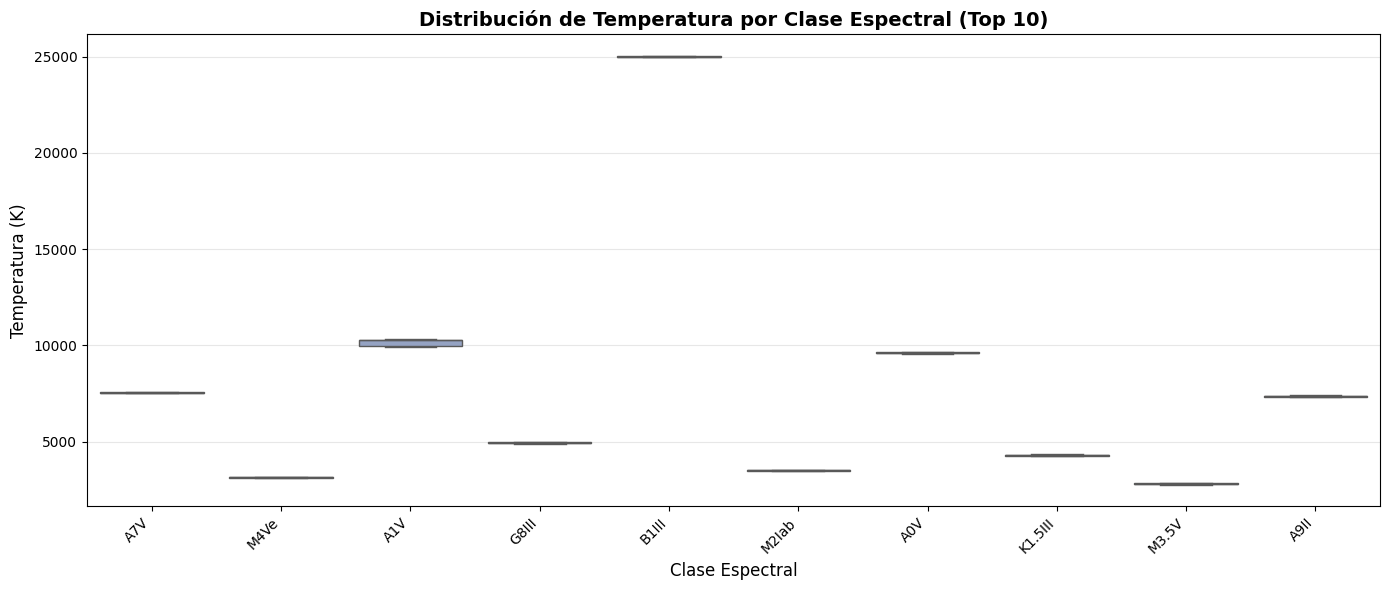

In [42]:
# Usa seaborn.boxplot para mostrar distribución de temperatura
# tu código aquí

# Filtrar para las 10 clases más frecuentes
top_clases = stars['Spectral Class'].value_counts().head(10).index
stars_top = stars[stars['Spectral Class'].isin(top_clases)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=stars_top, x='Spectral Class', y='Temperature (K)', palette='Set2')
plt.title('Distribución de Temperatura por Clase Espectral (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Clase Espectral', fontsize=12)
plt.ylabel('Temperatura (K)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

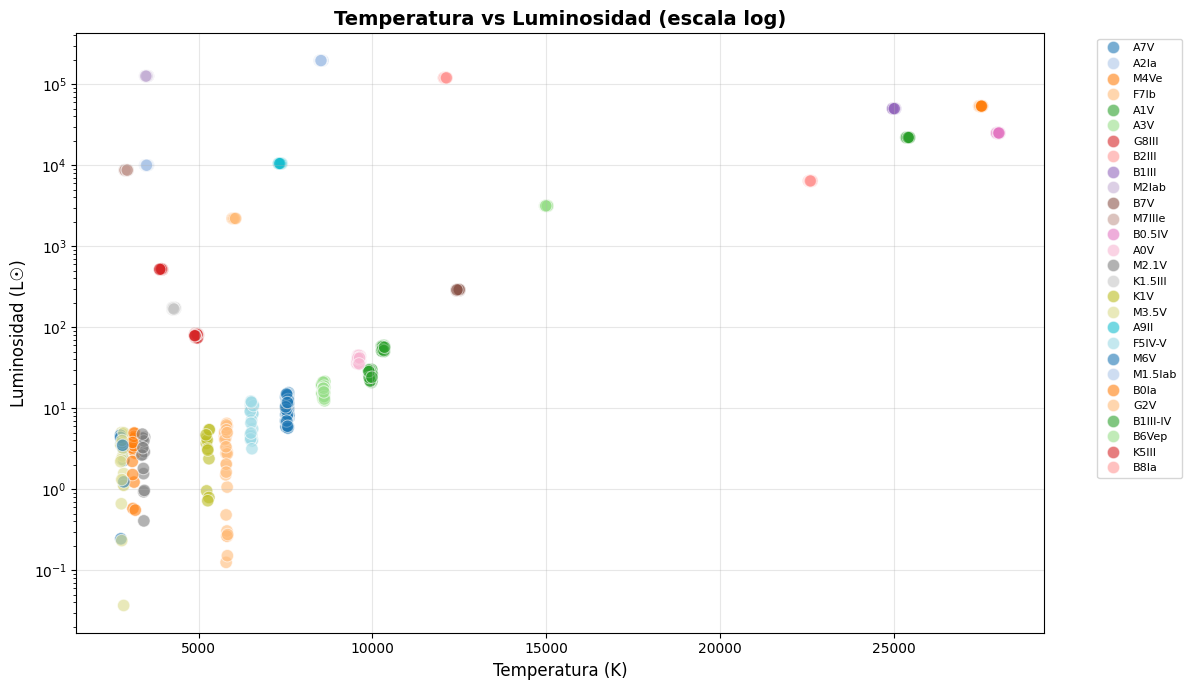

In [34]:
# - X: Temperature (K)
# - Y: Luminosity (L/Lo) con escala logarítmica
# - Colorear por Spectral Class
# tu código aquí

plt.figure(figsize=(12, 7))
sns.scatterplot(data=stars, x='Temperature (K)', y='Luminosity (L/Lo)', 
                hue='Spectral Class', s=80, alpha=0.6, palette='tab20')
plt.yscale('log')
plt.title('Temperatura vs Luminosidad (escala log)', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('Luminosidad (L☉)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [43]:
# Usa np.mean(), np.median(), np.std()
# tu código aquí
temperaturas = stars['Temperature (K)'].values

media_temp = np.mean(temperaturas)
mediana_temp = np.median(temperaturas)
desv_temp = np.std(temperaturas)

print(f"Media de temperatura: {media_temp:.2f} K")
print(f"Mediana de temperatura: {mediana_temp:.2f} K")
print(f"Desviación estándar: {desv_temp:.2f} K")


Media de temperatura: 9983.49 K
Mediana de temperatura: 7379.01 K
Desviación estándar: 7903.02 K


In [45]:
# Usa np.percentile() para calcular percentiles 25, 50, 75, 90 del radio
# tu código aquí
radios = stars['Radius (R/Ro)'].values

p25 = np.percentile(radios, 25)
p50 = np.percentile(radios, 50)
p75 = np.percentile(radios, 75)
p90 = np.percentile(radios, 90)

print(f"Percentil 25: {p25:.4f} R☉")
print(f"Percentil 50 (mediana): {p50:.4f} R☉")
print(f"Percentil 75: {p75:.4f} R☉")
print(f"Percentil 90: {p90:.4f} R☉")


Percentil 25: 1.6645 R☉
Percentil 50 (mediana): 5.8454 R☉
Percentil 75: 33.7198 R☉
Percentil 90: 369.9267 R☉


---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

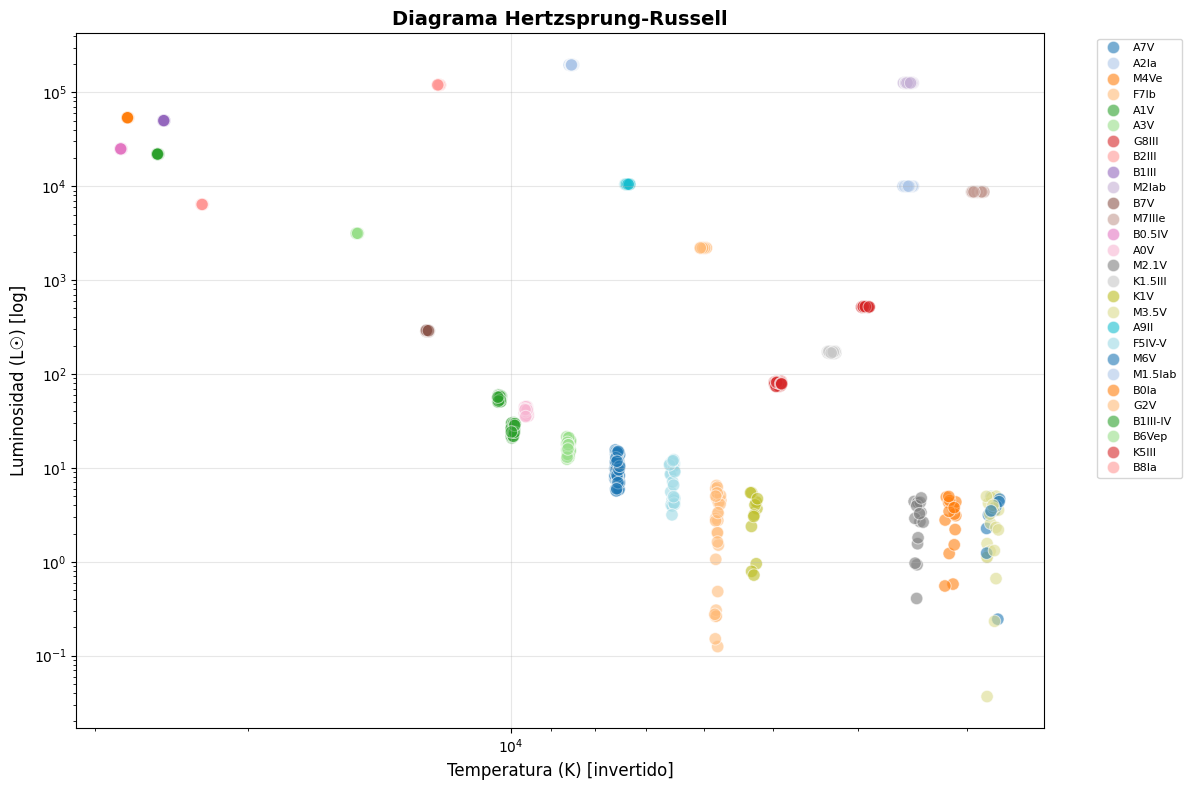

In [46]:
# Crea el Diagrama Hertzsprung-Russell
# tu código aquí

plt.figure(figsize=(12, 8))
sns.scatterplot(data=stars, x='Temperature (K)', y='Luminosity (L/Lo)', 
                hue='Spectral Class', s=80, alpha=0.6, palette='tab20')

# Escala logarítmica en ambos ejes
plt.yscale('log')
plt.xscale('log')

# Invertir eje X (temperaturas más altas a la izquierda)
plt.gca().invert_xaxis()

plt.title('Diagrama Hertzsprung-Russell', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura (K) [invertido]', fontsize=12)
plt.ylabel('Luminosidad (L☉) [log]', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()